This notebook experiments on KAN with hidden layers, which requires implementing an affine transformation.

In [61]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np


from importlib import reload
import kan
reload(kan)

from kan import KAN

In [62]:
x_min_test = 0
x_max_test = 1

In [63]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

selected_indices = kan.select_equidistant_basis_indices(
    total_basis=b_coef.shape[0],
    num_selected=16,
)
#selected_indices = np.arange(12)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

Selected indices: [ 0  2  4  7  9 11 13 15 18 20 22 24 26 29 31 33]
Selected detunings: tensor([-5.0000e+10, -7.0000e+10, -9.0000e+10, -1.2000e+11, -1.4000e+11,
        -1.6000e+11, -1.8000e+11, -2.0000e+11, -2.3000e+11, -2.5000e+11,
        -2.7000e+11, -2.9000e+11, -3.1000e+11, -3.4000e+11, -3.6000e+11,
        -3.8000e+11])
Selected b_coef shape: torch.Size([16, 8])


In [64]:
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_train = 3000
n_test = 800

x_max_test = 1
x_min_test = 0
input_abs_max = max(abs(x_min_test), abs(x_max_test))

x_train = x_min_test + (x_max_test - x_min_test) * torch.rand(n_train, 2)
x_test = x_min_test + (x_max_test - x_min_test) * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    y = torch.exp(torch.sin(torch.pi * x1) + x2**2)

    return y

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [65]:
model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[1],   # [2, 1, 1] KAN
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    layer_type="photonic_interval_affine_clean",
    b_coef_selected=b_coef_selected,
    input_abs_max=input_abs_max,
    basis_min=0.05,
    basis_max=2.0,
    dropout_prob=0.0,
    debug=False,
)

model = model.to(device=device, dtype=torch.float64)

In [66]:
x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)
x_test = x_test.to(device=device, dtype=torch.float64)
y_test = y_test.to(device=device, dtype=torch.float64)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

num_epochs = 5000

train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"train loss = {loss.item():.8f} | "
            f"test loss = {test_loss.item():.8f}"
        )

Epoch     0 | train loss = 9.87591412 | test loss = 9.29868657
Epoch   500 | train loss = 0.36373717 | test loss = 0.35619101
Epoch  1000 | train loss = 0.01770756 | test loss = 0.01561794
Epoch  1500 | train loss = 0.00743317 | test loss = 0.00721411
Epoch  2000 | train loss = 0.00527231 | test loss = 0.00528051
Epoch  2500 | train loss = 0.00429236 | test loss = 0.00433568
Epoch  3000 | train loss = 0.00357080 | test loss = 0.00362954
Epoch  3500 | train loss = 0.00295468 | test loss = 0.00302390
Epoch  4000 | train loss = 0.00245071 | test loss = 0.00252061
Epoch  4500 | train loss = 0.00208563 | test loss = 0.00214723


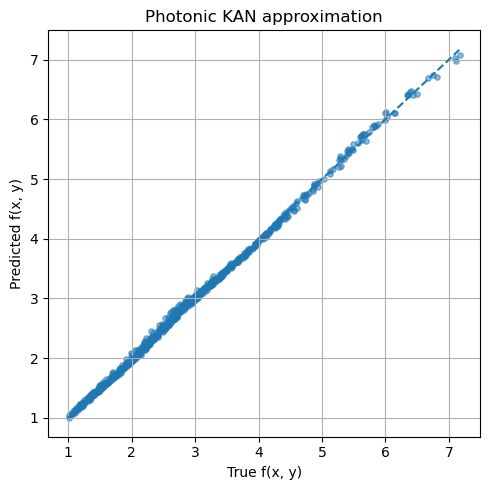

In [67]:
model.eval()

with torch.no_grad():
    y_pred_test = model(x_test)

plt.figure(figsize=(5, 5))
plt.scatter(
    y_test.detach().cpu().numpy(),
    y_pred_test.detach().cpu().numpy(),
    alpha=0.5,
    s=15,
)

minv = min(y_test.min().item(), y_pred_test.min().item())
maxv = max(y_test.max().item(), y_pred_test.max().item())

plt.plot([minv, maxv], [minv, maxv], linestyle="--")
plt.xlabel("True f(x, y)")
plt.ylabel("Predicted f(x, y)")
plt.title("Photonic KAN approximation")
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
model.eval()

with torch.no_grad():
    y_pred, activations = model(x_train, return_all=True)

z = activations[1]

z_min = z.min().item()
z_max = z.max().item()

print("hidden min:", z.min().item())
print("hidden max:", z.max().item())

hidden min: 0.5006933687201132
hidden max: 2.633490677216045


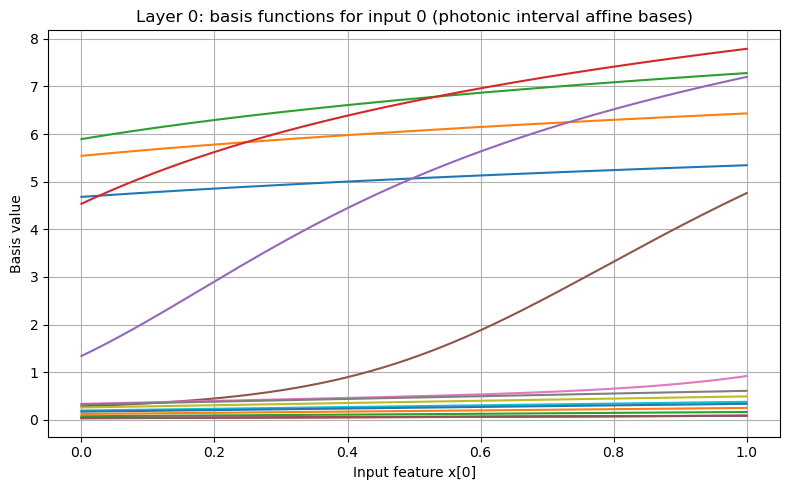

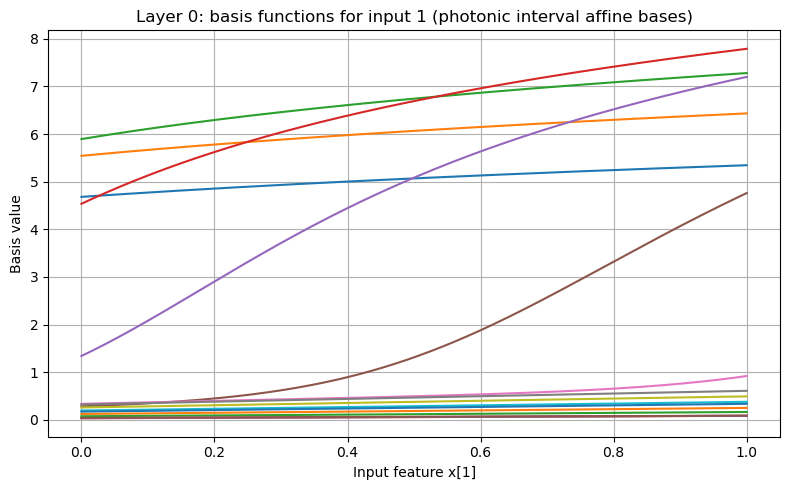

basis shape: torch.Size([400, 16])
basis finite: True
phi finite: True


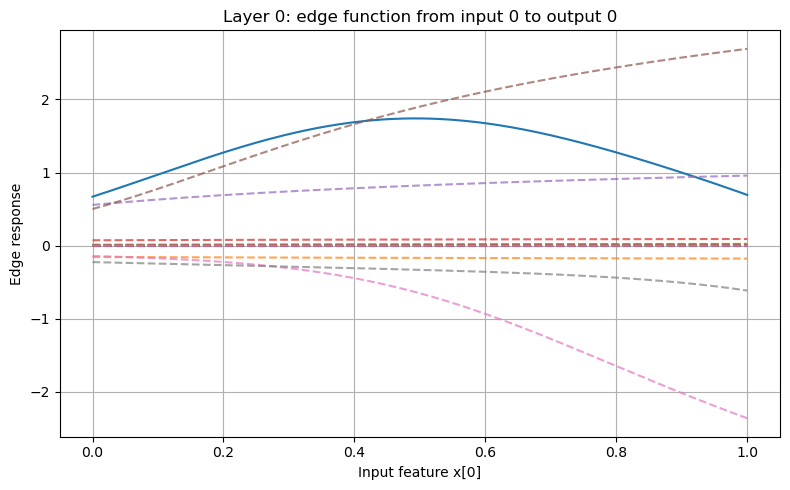

basis shape: torch.Size([400, 16])
basis finite: True
phi finite: True


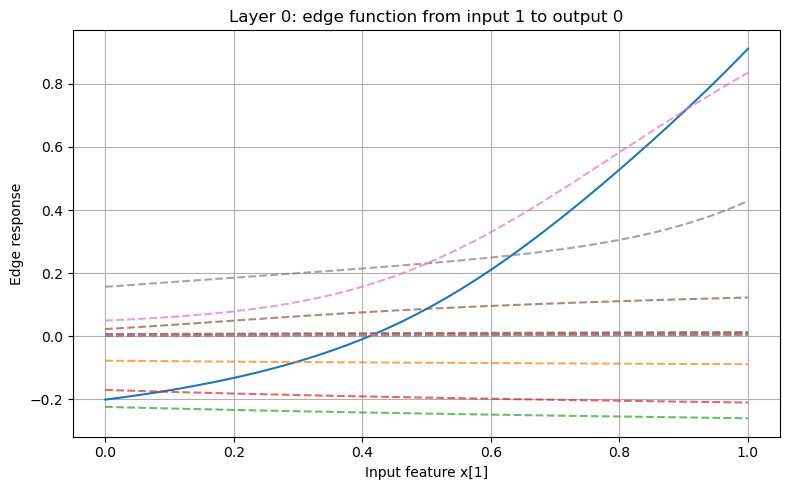

basis shape: torch.Size([400, 16])
basis finite: True
phi finite: True


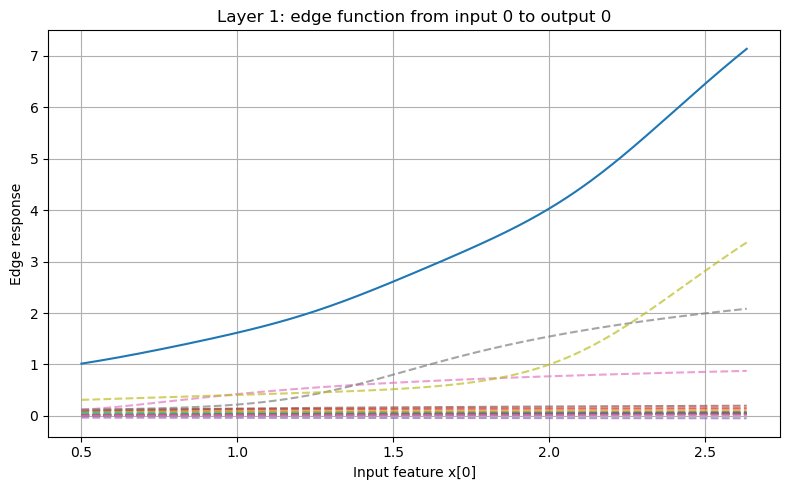

In [69]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test))
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test))

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True)
model.plot_edge_function(layer_idx=1, out_idx=0, in_idx=0, x_range=(z_min, z_max), show_basis=True)

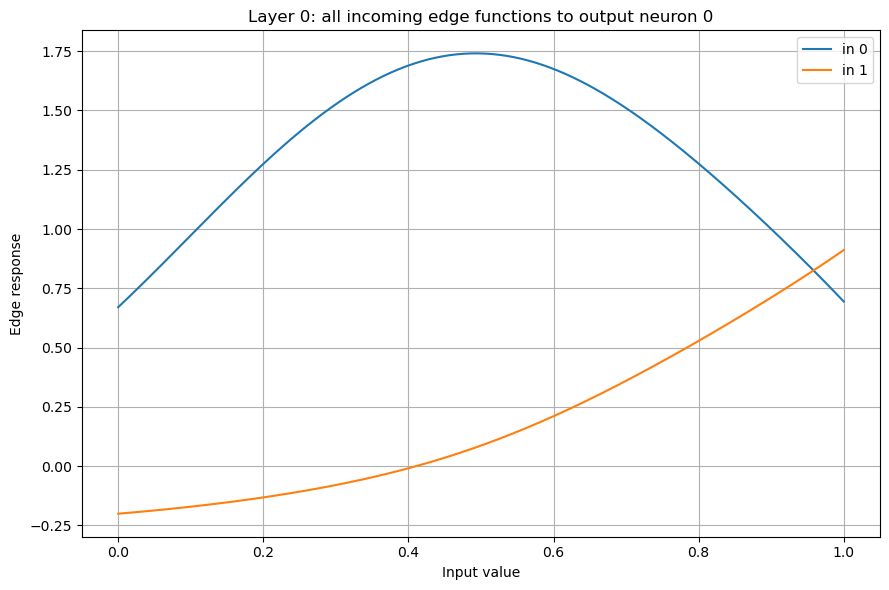

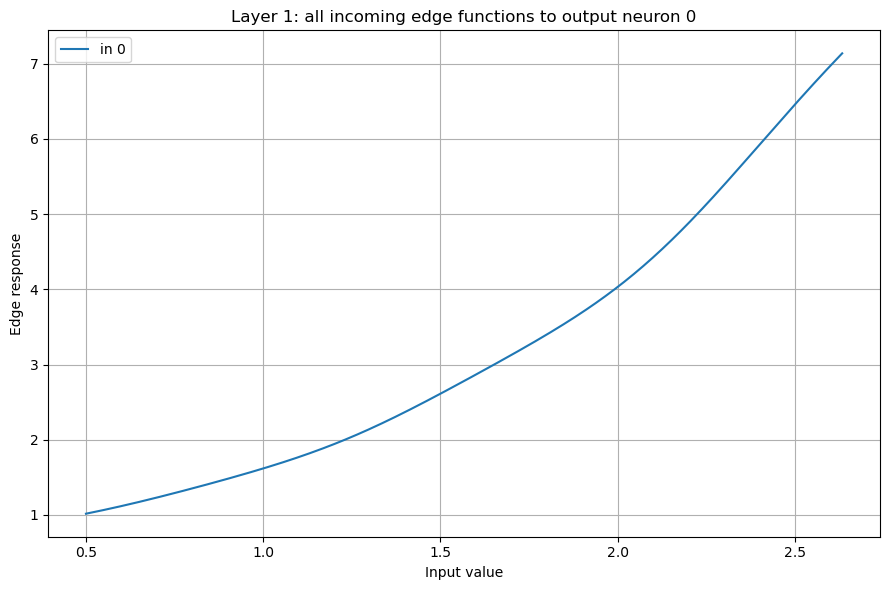

In [70]:
model.plot_all_incoming_edges(layer_idx=0, out_idx=0, x_range=(x_min_test, x_max_test))
model.plot_all_incoming_edges(layer_idx=1, out_idx=0, x_range=(z_min, z_max))

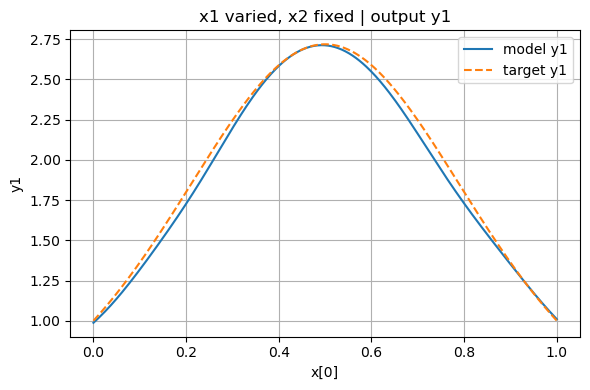

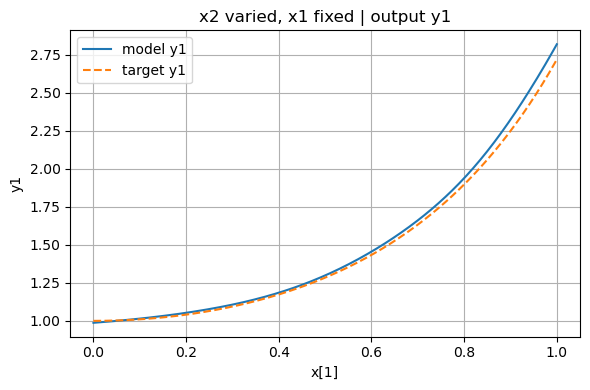

In [71]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.0, 0.0],
    resolution=400,
)

In [72]:
model.eval()

with torch.no_grad():
    y_out, stats, activations = model(
        x_train,
        track_stats=True,
        return_all=True,
    )

for s in stats:
    print(s)

{'min_input': tensor(0.0010, dtype=torch.float64), 'max_input': tensor(0.9998, dtype=torch.float64), 'min_affine_input': tensor(1.0260, dtype=torch.float64), 'max_affine_input': tensor(1.9998, dtype=torch.float64), 'min_basis': tensor(0.0338, dtype=torch.float64), 'max_basis': tensor(7.7903, dtype=torch.float64), 'min_output': tensor(0.5007, dtype=torch.float64), 'max_output': tensor(2.6335, dtype=torch.float64), 'layer': 0}
{'min_input': tensor(0.5007, dtype=torch.float64), 'max_input': tensor(2.6335, dtype=torch.float64), 'min_affine_input': tensor(1.5132, dtype=torch.float64), 'max_affine_input': tensor(3.5927, dtype=torch.float64), 'min_basis': tensor(0.0574, dtype=torch.float64), 'max_basis': tensor(9.9897, dtype=torch.float64), 'min_output': tensor(1.0164, dtype=torch.float64), 'max_output': tensor(7.1380, dtype=torch.float64), 'layer': 1}


### Include calibration

In [ ]:
x_min_test = 0
x_max_test = 1.0

first_layer_input_abs_max = max(abs(x_min_test), abs(x_max_test))

model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[1],
    layer_type="photonic_interval_affine_clean",
    b_coef_selected=b_coef_selected,
    input_abs_max=first_layer_input_abs_max,
    basis_min=0.05,
    basis_max=2.0,
    dropout_prob=0.0,
    debug=False,
)

model = model.to(device=device, dtype=torch.float64)

x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)

model.calibrate_input_abs_max_by_layer(
    x_train,
    first_layer_input_abs_max=first_layer_input_abs_max,
    margin=1.25,
    verbose=True,
)

TypeError: KAN.__init__() got an unexpected keyword argument 'input_abs_max'

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

num_epochs = 5000

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred, stats = model(x_train, track_stats=True)
    loss = loss_fn(y_pred, y_train)

    if not torch.isfinite(loss):
        print(f"NaN/Inf loss at epoch {epoch}")
        for s in stats:
            print(
                f"Layer {s['layer']} | "
                f"input [{s['min_input'].item():.4g}, {s['max_input'].item():.4g}] | "
                f"affine [{s['min_affine_input'].item():.4g}, {s['max_affine_input'].item():.4g}] | "
                f"basis [{s['min_basis'].item():.4g}, {s['max_basis'].item():.4g}] | "
                f"output [{s['min_output'].item():.4g}, {s['max_output'].item():.4g}]"
            )
        break

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if epoch % 500 == 0:
        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(x_test), y_test)

        print(
            f"Epoch {epoch:5d} | "
            f"train loss = {loss.item():.8f} | "
            f"test loss = {test_loss.item():.8f}"
        )

Epoch     0 | train loss = 9.84736494 | test loss = 9.44039829
Epoch   500 | train loss = 1.07372064 | test loss = 0.98925673
Epoch  1000 | train loss = 0.71457118 | test loss = 0.69514992
Epoch  1500 | train loss = 0.59344307 | test loss = 0.58248700
Epoch  2000 | train loss = 0.39910903 | test loss = 0.38581099
Epoch  2500 | train loss = 0.19858330 | test loss = 0.18790660
Epoch  3000 | train loss = 0.15669717 | test loss = 0.14792790
Epoch  3500 | train loss = 0.12625204 | test loss = 0.11801900
Epoch  4000 | train loss = 0.10660699 | test loss = 0.09850664
Epoch  4500 | train loss = 0.09391580 | test loss = 0.08648368


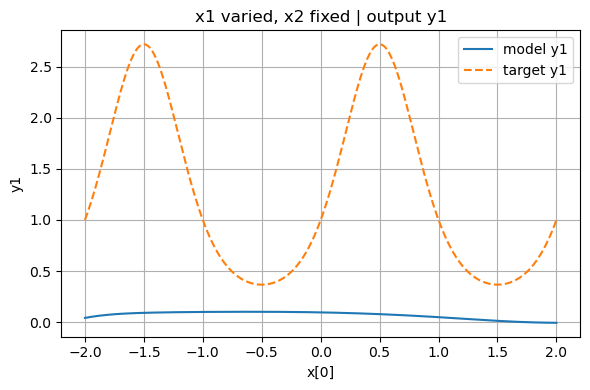

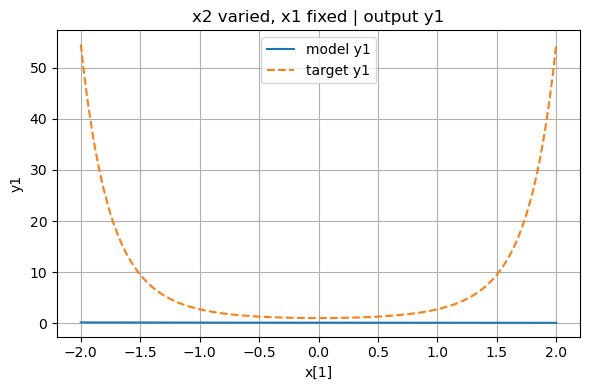

In [ ]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.0, 0.0],
    resolution=400,
)

In [57]:
x_min_test = -2.0
x_max_test = 2.0

model = KAN(
    in_count=2,
    out_count=1,
    hidden_layer_sizes=[1],
    layer_type="photonic_interval_affine_clean",
    b_coef_selected=b_coef_selected,
    input_min_by_layer=[x_min_test, -1.0],
    input_max_by_layer=[x_max_test,  1.0],
    basis_min=0.05,
    basis_max=1.0,
    dropout_prob=0.0,
    debug=False,
)

In [58]:
model = model.to(device=device, dtype=torch.float64)

x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)
x_test = x_test.to(device=device, dtype=torch.float64)
y_test = y_test.to(device=device, dtype=torch.float64)

model.calibrate_input_ranges_by_layer(
    x_train,
    first_layer_input_min=x_min_test,
    first_layer_input_max=x_max_test,
    margin=1.25,
    verbose=True,
)

Layer 0: calibrated input range [-2, 2]
Layer 1: calibrated input range [0.0926861, 0.159842]


In [59]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

num_epochs = 5000

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred, stats = model(x_train, track_stats=True)
    loss = loss_fn(y_pred, y_train)

    if not torch.isfinite(loss):
        print(f"NaN/Inf loss at epoch {epoch}")
        for s in stats:
            print(
                f"Layer {s['layer']} | "
                f"input [{s['min_input'].item():.4g}, {s['max_input'].item():.4g}] | "
                f"affine [{s['min_affine_input'].item():.4g}, {s['max_affine_input'].item():.4g}] | "
                f"basis [{s['min_basis'].item():.4g}, {s['max_basis'].item():.4g}] | "
                f"output [{s['min_output'].item():.4g}, {s['max_output'].item():.4g}]"
            )
        break

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if epoch % 500 == 0:
        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(x_test), y_test)

        print(
            f"Epoch {epoch:5d} | "
            f"train loss = {loss.item():.8f} | "
            f"test loss = {test_loss.item():.8f}"
        )

Epoch     0 | train loss = 10.66530085 | test loss = 10.21482080
NaN/Inf loss at epoch 3
Layer 0 | input [0.001031, 0.9998] | affine [0.5252, 0.7625] | basis [0.01461, 5.117] | output [0.08827, 0.1448]
Layer 1 | input [0.08827, 0.1448] | affine [-0.01245, 0.7875] | basis [nan, nan] | output [nan, nan]


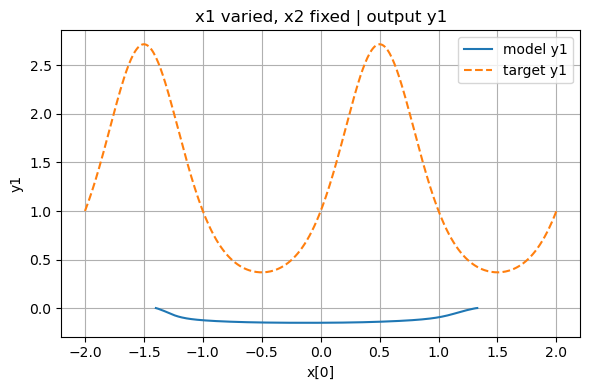

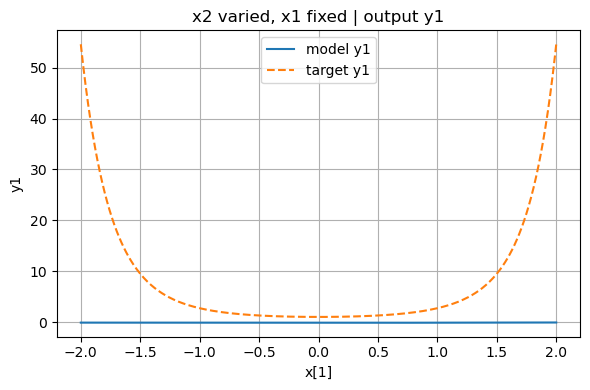

In [60]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[0.0, 0.0],
    resolution=400,
)